In [22]:
!pip install vnstock

In [23]:
import pandas as pd

df_vcb = pd.read_excel('VCB_history.csv.xlsx', header=5)
df_vcb['symbol'] = 'VCB'

df_tcb = pd.read_excel('TCB_history.csv.xlsx', header=5)
df_tcb['symbol'] = 'TCB'

df_bid = pd.read_excel('BID_history.csv.xlsx', header=5)
df_bid['symbol'] = 'BID'

df_all = pd.concat([df_vcb, df_tcb, df_bid])
df_all.head()

Workbook contains no default style, apply openpyxl's default
Workbook contains no default style, apply openpyxl's default
Workbook contains no default style, apply openpyxl's default


,NGÀY,GIÁ MỞ CỬA,GIÁ CAO NHẤT,GIÁ THẤP NHẤT,GIÁ ĐÓNG CỬA,THAY ĐỔI GIÁ,% THAY ĐỔI,KHỐI LƯỢNG,symbol
0,28/08/2026,60200.0,60500.0,59800.0,60100.0,0.0,0.000000,3386900.0,VCB
1,27/08/2026,60500.0,61400.0,60000.0,60100.0,-200.0,-0.003317,4904300.0,VCB
2,26/08/2026,59200.0,60300.0,59200.0,60300.0,900.0,0.015152,7177300.0,VCB
3,25/08/2026,59300.0,60200.0,59200.0,59400.0,200.0,0.003378,5577200.0,VCB
4,24/08/2026,60200.0,60500.0,59200.0,59200.0,100.0,0.001692,4773600.0,VCB


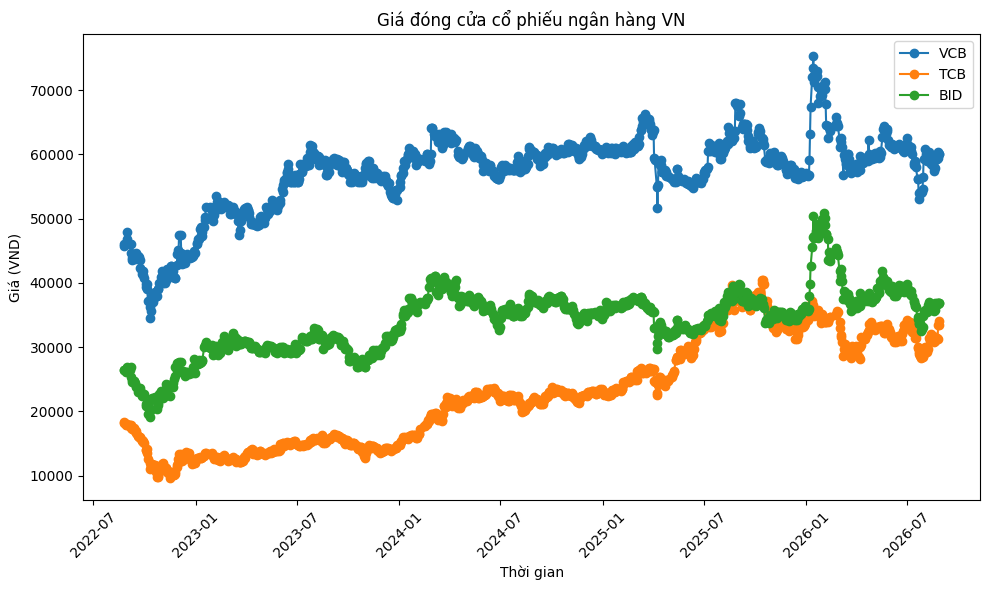

In [24]:
import matplotlib.pyplot as plt

# Chuyển cột ngày từ dạng chữ sang dạng ngày tháng thật
df_all['NGÀY'] = pd.to_datetime(df_all['NGÀY'], format='%d/%m/%Y', errors='coerce')

# Xóa các dòng bị lỗi (không chuyển được thành ngày hợp lệ)
df_all = df_all.dropna(subset=['NGÀY'])

# Sắp xếp lại theo thứ tự thời gian tăng dần (cũ -> mới)
df_all = df_all.sort_values('NGÀY')

plt.figure(figsize=(10,6))
for symbol in ['VCB', 'TCB', 'BID']:
    data = df_all[df_all['symbol'] == symbol]
    plt.plot(data['NGÀY'], data['GIÁ ĐÓNG CỬA'], label=symbol, marker='o')

plt.title('Giá đóng cửa cổ phiếu ngân hàng VN')
plt.xlabel('Thời gian')
plt.ylabel('Giá (VND)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bieudo_gia_ngan_hang.png')
plt.show()

